In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [53]:
from google.colab import files
uploaded=files.upload()

Saving credit_card_fraud_10k.csv to credit_card_fraud_10k (1).csv


In [54]:
df=pd.read_csv("credit_card_fraud_10k.csv")
print(df.head())
print(df.shape)

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [55]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None


In [56]:
print(df.describe())

       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0.000000     

In [57]:
print(df["is_fraud"].value_counts())

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [58]:
df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)

In [59]:
X = df.drop(["is_fraud", "transaction_id"], axis=1)
y = df["is_fraud"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train, y_train
)

print("After SMOTE:")
print(y_train.value_counts())


After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [62]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [63]:
probability = model.predict_proba(X_test)[:, 1]

In [64]:
for threshold in [0.3, 0.5, 0.7]:

    prediction = (probability >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print(classification_report(y_test, prediction))



Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.25      0.87      0.39        30

    accuracy                           0.96      2000
   macro avg       0.63      0.91      0.69      2000
weighted avg       0.99      0.96      0.97      2000


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.35      0.83      0.49        30

    accuracy                           0.97      2000
   macro avg       0.67      0.90      0.74      2000
weighted avg       0.99      0.97      0.98      2000


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.49      0.80      0.61        30

    accuracy                           0.98      2000
   macro avg       0.74      0.89      0.80      2000
weighted avg       0.99   

In [65]:
prediction = (probability >= 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))


Confusion Matrix:
[[1923   47]
 [   5   25]]


In [66]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Features:")
print(importance.head(10))


Top Features:
device_trust_score               0.287299
transaction_hour                 0.191259
foreign_transaction              0.114583
velocity_last_24h                0.084572
location_mismatch                0.077038
merchant_category_Travel         0.060887
merchant_category_Grocery        0.053376
amount                           0.037606
merchant_category_Electronics    0.037438
merchant_category_Food           0.036161
dtype: float32


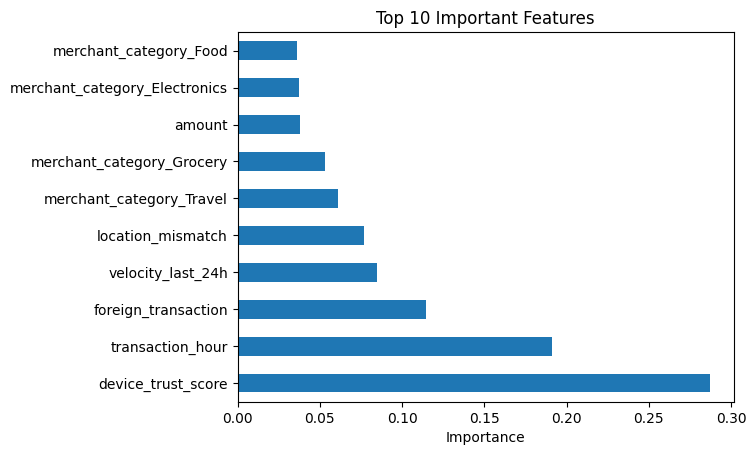

In [67]:
importance.head(10).plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()